Device: cpu
Seed: 7772

Loading data...
Snow season days: 2410
Observations: 37

Running LOO with daily simulation for seed 7772...
  5/37
  10/37
  15/37
  20/37
  25/37
  30/37
  35/37
Daily simulation completed: 505 days
Daily predictions saved to tables/pinn_daily_simulation_seed7772.csv
LOO metrics (Seed 7772):
  PINN MAE = 9.01 mm
  ERA5 MAE = 19.84 mm
  PINN RMSE = 18.28 mm
  PINN NSE = 0.874
  PINN KGE = 0.889
  Wilcoxon p-value = 0.00000
  Improved points = 89.2%


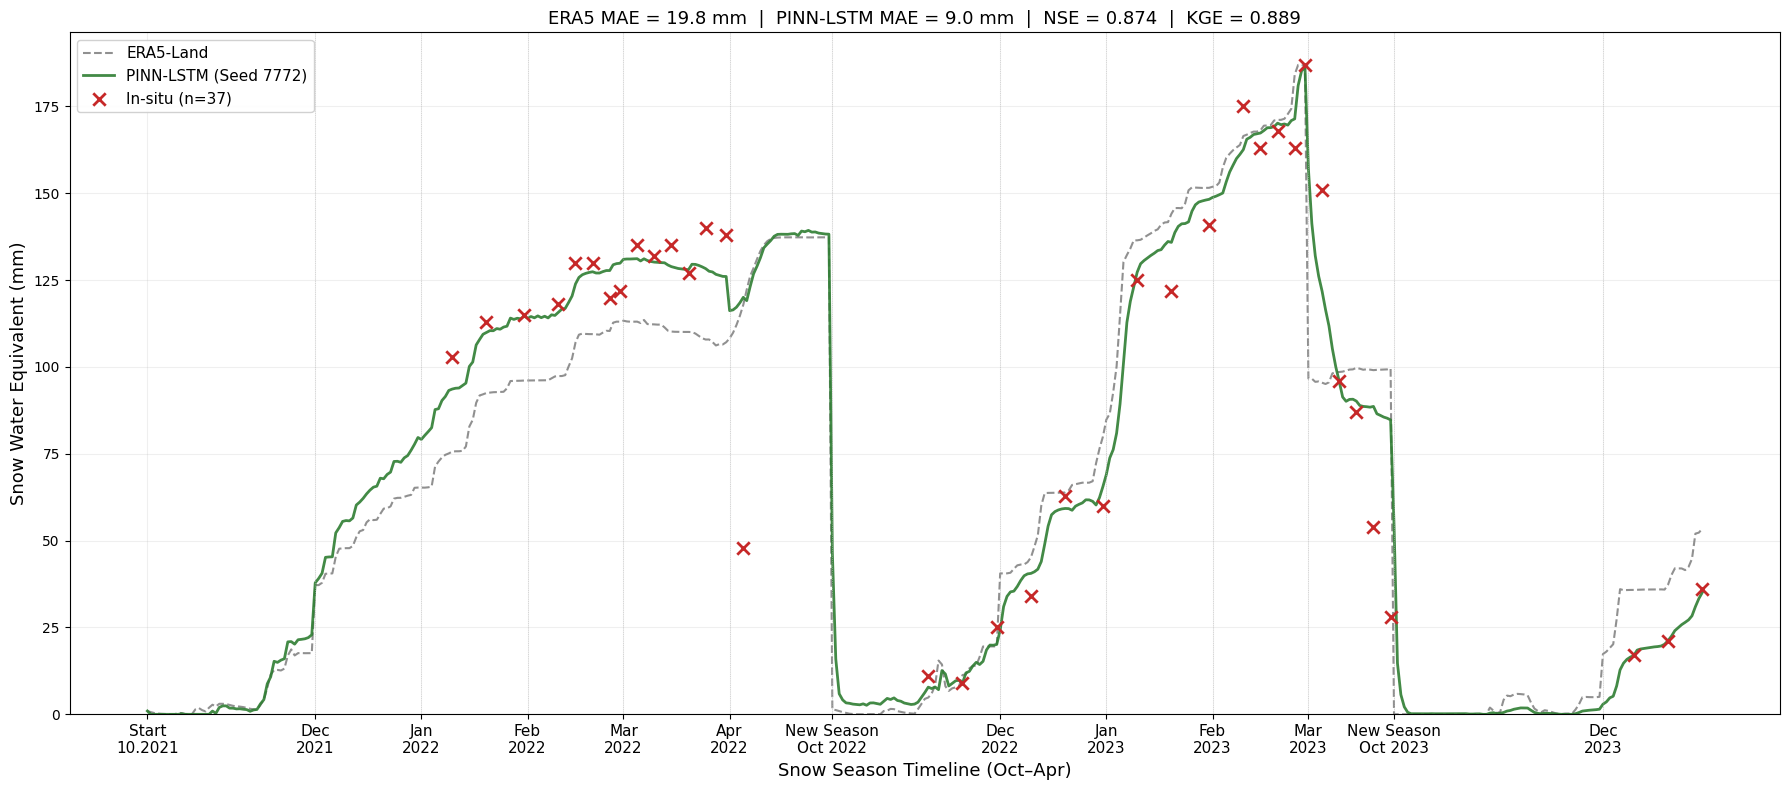


Figure saved to figures/pinn_daily_simulation_seed7772_Oct_Apr.png/pdf
Daily simulation experiment completed.


In [1]:
# ============================================================
# Supplementary: PINN LOO + Daily Continuous Simulation
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Settings
# ============================================================
SEED = 7772
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FIG_DIR = 'figures'
TABLE_DIR = 'tables'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

DATA_PATH = '../../data_preprocessing/processed/shemonaikha_snow_dataset_2014_2023.csv'
OBS_PATH = '../../data_preprocessing/data/shemonaikha.csv'

print(f"Device: {DEVICE}")
print(f"Seed: {SEED}")

# ============================================================
# Load and prepare data
# ============================================================
print("\nLoading data...")
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['era5_swe'] = df['swe_final']

obs = pd.read_csv(OBS_PATH)
obs['Date'] = obs['Date'].astype(str).str.replace('"', '').str.strip()
obs['Date'] = obs['Date'].str.replace(',$', '', regex=True)
obs['Date'] = pd.to_datetime(obs['Date'], format='%d.%m.%Y %H:%M')
obs['SWE'] = pd.to_numeric(obs['SWE'].astype(str).str.replace('"', '').str.replace(',', ''), errors='coerce')
obs['date'] = obs['Date'].dt.date
obs = obs.drop_duplicates(subset=['date']).copy()
obs['date'] = pd.to_datetime(obs['date'])
station_dict = dict(zip(obs['date'], obs['SWE']))
df['observed_swe'] = df['date'].map(station_dict)

# Snow season only (Oct-May)
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['water_year'] = df['year'] + (df['month'] >= 10).astype(int)
df_snow = df[(df['month'] >= 10) | (df['month'] <= 5)].copy().reset_index(drop=True)

print(f"Snow season days: {len(df_snow)}")
print(f"Observations: {df_snow['observed_swe'].notna().sum()}")

# ============================================================
# Feature engineering (same as main PINN notebook)
# ============================================================
def create_features(df_subset):
    n = len(df_subset)
    def get_vals(col):
        vals = df_subset[col]
        return vals.iloc[:, 0].values if isinstance(vals, pd.DataFrame) else vals.values

    temp = get_vals('temperature_2m_C')
    precip = get_vals('precipitation_mm')
    snow_cover = get_vals('snow_cover_ERA5')
    albedo = get_vals('forecast_albedo')
    snowmelt = get_vals('snowmelt_sum')
    solar_down = get_vals('surface_solar_radiation_downwards_sum')
    thermal_down = get_vals('surface_thermal_radiation_downwards_sum')
    u_wind = get_vals('u_component_of_wind_10m')
    v_wind = get_vals('v_component_of_wind_10m')
    soil_water = get_vals('volumetric_soil_water_layer_1')
    water_year = get_vals('water_year')
    doy = get_vals('doy')

    features = {}
    features['temperature_2m_C'] = temp
    features['precipitation_mm'] = precip
    features['snow_cover_ERA5'] = snow_cover
    features['forecast_albedo'] = albedo
    features['snowmelt_sum'] = snowmelt
    features['surface_solar_radiation_downwards_sum'] = solar_down
    features['surface_thermal_radiation_downwards_sum'] = thermal_down
    features['u_component_of_wind_10m'] = u_wind
    features['v_component_of_wind_10m'] = v_wind
    features['volumetric_soil_water_layer_1'] = soil_water

    features['wind_speed'] = np.sqrt(u_wind**2 + v_wind**2)
    albedo_clipped = np.clip(albedo, 0.3, 0.95)
    features['solar_net'] = solar_down * (1 - albedo_clipped)
    features['thermal_net'] = (thermal_down - 5.67e-8 * 273.15**4) / 1e6
    features['temp_melt_potential'] = np.maximum(temp - 0.5, 0)
    features['soil_moisture_pct'] = soil_water * 100
    features['doy_sin'] = np.sin(2 * np.pi * doy / 365)
    features['doy_cos'] = np.cos(2 * np.pi * doy / 365)

    unique_wy = np.unique(water_year)
    for lag in [1, 2, 3]:
        temp_lag = np.full(n, np.nan)
        precip_lag = np.full(n, np.nan)
        for wy in unique_wy:
            mask = water_year == wy
            idx = np.where(mask)[0]
            if len(idx) > lag:
                temp_lag[idx[lag:]] = temp[idx[:-lag]]
                precip_lag[idx[lag:]] = precip[idx[:-lag]]
        features[f'temp_lag{lag}'] = temp_lag
        features[f'precip_lag{lag}'] = precip_lag

    cumul_precip = np.full(n, np.nan)
    cumul_snowmelt = np.full(n, np.nan)
    for wy in unique_wy:
        mask = water_year == wy
        cumul_precip[mask] = np.cumsum(precip[mask])
        cumul_snowmelt[mask] = np.cumsum(snowmelt[mask])
    features['cumul_precip'] = cumul_precip
    features['cumul_snowmelt'] = cumul_snowmelt

    df_feat = pd.DataFrame(features, index=df_subset.index)
    df_feat = df_feat.ffill().fillna(0)
    return df_feat

# ============================================================
# PINN model and loss
# ============================================================
class StablePINN(nn.Module):
    def __init__(self, feature_names):
        super().__init__()
        self.feature_names = feature_names
        self.raw_temp_melt = nn.Parameter(torch.tensor(0.5))
        self.raw_solar_melt = nn.Parameter(torch.tensor(-2.0))
        self.raw_thermal_melt = nn.Parameter(torch.tensor(-2.5))
        self.raw_wind_subl = nn.Parameter(torch.tensor(-3.0))
        self.raw_snow_threshold = nn.Parameter(torch.tensor(0.3))
        self.physics_weight = nn.Parameter(torch.tensor(0.5))
        self.era5_weight = nn.Parameter(torch.tensor(0.5))
        self.corrector = nn.Sequential(
            nn.Linear(12, 24), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(24, 12), nn.ReLU(), nn.Linear(12, 1), nn.Tanh()
        )
        self.correction_scale = nn.Parameter(torch.tensor(1.0))

    @property
    def temp_melt_factor(self):
        return torch.nn.functional.softplus(self.raw_temp_melt) * 2.0
    @property
    def solar_melt_factor(self):
        return torch.nn.functional.softplus(self.raw_solar_melt) * 0.05
    @property
    def thermal_melt_factor(self):
        return torch.nn.functional.softplus(self.raw_thermal_melt) * 0.01
    @property
    def wind_sublimation_factor(self):
        return torch.nn.functional.softplus(self.raw_wind_subl) * 0.01
    @property
    def snow_threshold(self):
        return torch.nn.functional.softplus(self.raw_snow_threshold) + 0.5

    def _get_idx(self, name):
        return self.feature_names.index(name)

    def physics_forward(self, x):
        t = x[:, self._get_idx('temperature_2m_C')]
        p = x[:, self._get_idx('precipitation_mm')]
        sc = x[:, self._get_idx('snow_cover_ERA5')] / 100.0
        sn = x[:, self._get_idx('solar_net')]
        tn = x[:, self._get_idx('thermal_net')]
        w = x[:, self._get_idx('wind_speed')]
        sm = x[:, self._get_idx('soil_moisture_pct')]
        tp = x[:, self._get_idx('temp_melt_potential')]

        snow_frac = torch.sigmoid(-3 * (t - self.snow_threshold))
        snowfall = p * snow_frac * torch.clamp(sc, min=0.05)
        temp_melt = self.temp_melt_factor * tp * sc
        solar_melt = self.solar_melt_factor * torch.clamp(sn, min=0) * sc
        thermal_melt = self.thermal_melt_factor * torch.clamp(tn, min=0) * sc
        soil_melt = 0.001 * sm * sc * tp
        sub_cond = torch.sigmoid(2 * (t + 5))
        sublimation = self.wind_sublimation_factor * w * sc * sub_cond
        total_melt = temp_melt + solar_melt + thermal_melt + soil_melt
        dswe_dt = snowfall - total_melt - sublimation
        return dswe_dt, snowfall, total_melt, sublimation

    def forward(self, x, swe_prev, era5_current, era5_prev):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        dswe_dt, snowfall, total_melt, sublimation = self.physics_forward(x)
        swe_physics = swe_prev + dswe_dt.unsqueeze(1)
        swe_physics = torch.clamp(swe_physics, min=0)
        w_phys = torch.sigmoid(self.physics_weight)
        w_era5 = torch.sigmoid(self.era5_weight)
        swe_blend = (w_phys * swe_physics + w_era5 * era5_current) / (w_phys + w_era5 + 1e-8)
        corr_features = torch.cat([
            dswe_dt.unsqueeze(1), snowfall.unsqueeze(1),
            total_melt.unsqueeze(1), sublimation.unsqueeze(1),
            (swe_physics - era5_current), (swe_prev - era5_prev),
            x[:, self._get_idx('temperature_2m_C')].unsqueeze(1),
            x[:, self._get_idx('snow_cover_ERA5')].unsqueeze(1) / 100.0,
            x[:, self._get_idx('cumul_precip')].unsqueeze(1) / 200.0,
            x[:, self._get_idx('cumul_snowmelt')].unsqueeze(1) / 200.0,
            x[:, self._get_idx('doy_sin')].unsqueeze(1),
            x[:, self._get_idx('doy_cos')].unsqueeze(1)
        ], dim=1)
        scale = torch.nn.functional.softplus(self.correction_scale) * 10.0
        correction = self.corrector(corr_features) * scale
        swe_corrected = swe_blend + correction
        swe_corrected = torch.clamp(swe_corrected, min=0)
        return swe_corrected, swe_physics, correction

    def run_sequence(self, X, era5_swe, warmup_steps=10):
        seq_len = X.shape[0]
        swe_pred = torch.zeros(seq_len, 1, device=X.device)
        swe_physics_out = torch.zeros(seq_len, 1, device=X.device)
        corr_out = torch.zeros(seq_len, 1, device=X.device)
        swe_pred[0] = era5_swe[0]
        swe_physics_out[0] = era5_swe[0]
        for t in range(1, seq_len):
            swe_pred[t], swe_physics_out[t], corr_out[t] = self(
                X[t:t+1], swe_pred[t-1:t],
                era5_swe[t:t+1], era5_swe[t-1:t]
            )
        warmup_mask = torch.zeros(seq_len, 1, dtype=torch.bool, device=X.device)
        warmup_mask[:warmup_steps] = True
        return swe_pred, swe_physics_out, corr_out, warmup_mask

def stable_loss(swe_pred, era5, obs, correction, active_mask):
    obs_mask = ~torch.isnan(obs) & active_mask
    if obs_mask.sum() > 0:
        diff = torch.abs(swe_pred[obs_mask] - obs[obs_mask])
        loss_obs = torch.where(diff < 10.0, 0.5 * diff**2, 10.0 * diff - 50.0).mean()
    else:
        loss_obs = torch.tensor(0.0, device=swe_pred.device)
    loss_era5 = torch.mean((swe_pred[active_mask] - era5[active_mask])**2) * 0.01
    loss_corr = torch.mean(correction[active_mask]**2) * 0.1
    swe_active = swe_pred[active_mask]
    loss_smooth = torch.mean(torch.abs(swe_active[1:] - swe_active[:-1])) * 0.001 if swe_active.shape[0] > 1 else torch.tensor(0.0, device=swe_pred.device)
    return loss_obs + loss_era5 + loss_corr + loss_smooth, loss_obs

# ============================================================
# Prepare observation indices
# ============================================================
obs_dates = df_snow[df_snow['observed_swe'].notna()]['date'].values
obs_indices = [df_snow[df_snow['date'] == d].index[0] for d in obs_dates]
y_true_loo = df_snow.loc[obs_indices, 'observed_swe'].values.astype(float)
era5_loo = df_snow.loc[obs_indices, 'era5_swe'].values.astype(float)

# ============================================================
# LOO with daily simulation
# ============================================================
print(f"\nRunning LOO with daily simulation for seed {SEED}...")

# Storage for daily predictions
daily_predictions = defaultdict(list)
daily_physics = defaultdict(list)
daily_correction = defaultdict(list)
daily_era5 = {}
daily_obs = {}

predictions_loo = []

for i, test_idx in enumerate(obs_indices):
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{len(obs_indices)}")

    start_idx = max(0, test_idx - 89)
    df_subset = df_snow.iloc[start_idx:test_idx+1].copy()
    df_features = create_features(df_subset)
    feature_names = df_features.columns.tolist()

    scaler = RobustScaler()
    scaled_feat = scaler.fit_transform(df_features.values)
    X = torch.FloatTensor(scaled_feat).to(DEVICE)
    era5 = torch.FloatTensor(df_subset['era5_swe'].values.reshape(-1, 1)).to(DEVICE)
    obs = torch.FloatTensor(df_subset['observed_swe'].values.reshape(-1, 1)).to(DEVICE)

    model = StablePINN(feature_names).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)

    for epoch in range(50):
        optimizer.zero_grad()
        swe_pred, _, corr, warmup = model.run_sequence(X, era5, warmup_steps=10)
        active = ~warmup
        loss, _ = stable_loss(swe_pred, era5, obs, corr, active)
        if not torch.isnan(loss):
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

    model.eval()
    with torch.no_grad():
        swe_pred, swe_phys, corr, _ = model.run_sequence(X, era5, warmup_steps=0)

    # Save LOO prediction
    predictions_loo.append(max(0, swe_pred[-1].item()))

    # Save daily predictions
    dates_subset = df_subset['date'].values
    for j, date in enumerate(dates_subset):
        daily_predictions[date].append(max(0, swe_pred[j].item()))
        daily_physics[date].append(max(0, swe_phys[j].item()))
        daily_correction[date].append(corr[j].item())
        daily_era5[date] = era5[j].item()
        daily_obs[date] = obs[j].item()

# Aggregate daily predictions
all_dates = sorted(daily_predictions.keys())
predictions_avg = [np.mean(daily_predictions[d]) for d in all_dates]
predictions_std = [np.std(daily_predictions[d]) if len(daily_predictions[d]) > 1 else 0 for d in all_dates]
physics_avg = [np.mean(daily_physics[d]) for d in all_dates]
correction_avg = [np.mean(daily_correction[d]) for d in all_dates]
era5_daily = [daily_era5[d] for d in all_dates]
obs_daily = [daily_obs[d] for d in all_dates]

print(f"Daily simulation completed: {len(all_dates)} days")

# ============================================================
# Save daily predictions to CSV
# ============================================================
df_daily = pd.DataFrame({
    'date': all_dates,
    'observed_swe': obs_daily,
    'ERA5_Land': era5_daily,
    'PINN_prediction': predictions_avg,
    'PINN_std': predictions_std,
    'PINN_physics': physics_avg,
    'PINN_correction': correction_avg,
    'n_predictions': [len(daily_predictions[d]) for d in all_dates],
    'bias_vs_ERA5': np.array(predictions_avg) - np.array(era5_daily),
    'absolute_error': np.abs(np.array(predictions_avg) - np.array(obs_daily))
})
df_daily['is_observed'] = df_daily['observed_swe'].notna()
df_daily.to_csv(os.path.join(TABLE_DIR, f'pinn_daily_simulation_seed{SEED}.csv'), index=False)
print(f"Daily predictions saved to {TABLE_DIR}/pinn_daily_simulation_seed{SEED}.csv")

# ============================================================
# LOO metrics
# ============================================================
predictions_loo = np.array(predictions_loo)

mae_era5 = mean_absolute_error(y_true_loo, era5_loo)
mae_pinn = mean_absolute_error(y_true_loo, predictions_loo)
rmse_pinn = np.sqrt(mean_squared_error(y_true_loo, predictions_loo))
nse_pinn = 1 - np.sum((y_true_loo - predictions_loo)**2) / np.sum((y_true_loo - y_true_loo.mean())**2)
r = np.corrcoef(y_true_loo, predictions_loo)[0, 1]
kge_pinn = 1 - np.sqrt((r - 1)**2 + (np.std(predictions_loo)/np.std(y_true_loo) - 1)**2 + (np.mean(predictions_loo)/np.mean(y_true_loo) - 1)**2)
_, p_val = stats.wilcoxon(np.abs(y_true_loo - era5_loo), np.abs(y_true_loo - predictions_loo))
improved_pct = np.mean(np.abs(y_true_loo - predictions_loo) < np.abs(y_true_loo - era5_loo)) * 100

print(f"LOO metrics (Seed {SEED}):")
print(f"  PINN MAE = {mae_pinn:.2f} mm")
print(f"  ERA5 MAE = {mae_era5:.2f} mm")
print(f"  PINN RMSE = {rmse_pinn:.2f} mm")
print(f"  PINN NSE = {nse_pinn:.3f}")
print(f"  PINN KGE = {kge_pinn:.3f}")
print(f"  Wilcoxon p-value = {p_val:.5f}")
print(f"  Improved points = {improved_pct:.1f}%")

# ============================================================
# Clean time series plot (Oct–Apr)
# ============================================================
all_dates_dt = pd.to_datetime(all_dates)
months_all = all_dates_dt.month.values
years_all = all_dates_dt.year.values
mask_oct_apr = (months_all >= 10) | (months_all <= 4)

dates_plot = all_dates_dt[mask_oct_apr]
predictions_plot = np.array(predictions_avg)[mask_oct_apr]
era5_plot = np.array(era5_daily)[mask_oct_apr]
obs_plot = np.array(obs_daily)[mask_oct_apr]
months_plot = months_all[mask_oct_apr]
years_plot = years_all[mask_oct_apr]

sort_idx = np.argsort(dates_plot)
dates_plot = dates_plot[sort_idx]
predictions_plot = predictions_plot[sort_idx]
era5_plot = era5_plot[sort_idx]
obs_plot = obs_plot[sort_idx]
months_plot = months_plot[sort_idx]
years_plot = years_plot[sort_idx]

x_continuous = np.arange(len(dates_plot))

# Season labels
season_labels = []
season_positions = []
prev_month = None
for i, (month, year) in enumerate(zip(months_plot, years_plot)):
    if i == 0:
        label = f"Start\n{month:02d}.{year}"
    elif month == 10 and prev_month and prev_month <= 4:
        label = f"New Season\nOct {year}"
    elif month == 12 and prev_month == 11:
        label = f"Dec\n{year}"
    elif month == 1 and prev_month == 12:
        label = f"Jan\n{year}"
    elif month == 2 and prev_month == 1:
        label = f"Feb\n{year}"
    elif month == 3 and prev_month == 2:
        label = f"Mar\n{year}"
    elif month == 4 and prev_month == 3:
        label = f"Apr\n{year}"
    else:
        label = ""
    if label and (len(season_positions) == 0 or i - season_positions[-1] > 20):
        season_labels.append(label)
        season_positions.append(i)
    prev_month = month

# Plot (no background shading)
fig, ax = plt.subplots(figsize=(18, 8))

ax.plot(x_continuous, era5_plot, color='#757575', linestyle='--', linewidth=1.5,
        label='ERA5-Land', alpha=0.8)
ax.plot(x_continuous, predictions_plot, color='#2E7D32', linewidth=2.0,
        label=f'PINN-LSTM (Seed {SEED})', alpha=0.9)

mask_obs_plot = ~np.isnan(obs_plot)
ax.scatter(x_continuous[mask_obs_plot], obs_plot[mask_obs_plot],
            marker='x', s=80, color='#C62828', label=f'In-situ (n={mask_obs_plot.sum()})',
            zorder=10, linewidth=2.0)

for pos in season_positions[1:]:
    ax.axvline(x=pos, color='#BDBDBD', linestyle=':', linewidth=0.6, alpha=0.7)

ax.set_xticks(season_positions)
ax.set_xticklabels(season_labels, fontsize=11)
ax.set_xlabel('Snow Season Timeline (Oct–Apr)', fontsize=13)
ax.set_ylabel('Snow Water Equivalent (mm)', fontsize=13)

all_vals = np.concatenate([era5_plot, predictions_plot, obs_plot[mask_obs_plot]])
ax.set_ylim(0, np.nanmax(all_vals) * 1.05)

delta_mae = mae_era5 - mae_pinn
improvement_pct = (delta_mae / mae_era5) * 100
ax.set_title(f'ERA5 MAE = {mae_era5:.1f} mm  |  PINN-LSTM MAE = {mae_pinn:.1f} mm  |  '
            f'NSE = {nse_pinn:.3f}  |  KGE = {kge_pinn:.3f}',
            fontsize=13)

ax.grid(True, alpha=0.2, linestyle='-')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9, edgecolor='#CCCCCC')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'pinn_daily_simulation_seed{SEED}_Oct_Apr.png'), dpi=300)
plt.savefig(os.path.join(FIG_DIR, f'pinn_daily_simulation_seed{SEED}_Oct_Apr.pdf'))
plt.show()

print(f"\nFigure saved to {FIG_DIR}/pinn_daily_simulation_seed{SEED}_Oct_Apr.png/pdf")
print("Daily simulation experiment completed.")